## Topic : Smart Expense Tracker Application

In [32]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

### Q1. Expense Input and Validation (Control Structure & Arrays)
#####  Accept user input for expenses, including the date, amount, category, and description.
#####  Validate inputs using control structures (e.g., ensure the amount is positive and the
##### category is valid).

In [3]:
expenses=[]
#Validate categories
valid_categories=["Food","Transport","Utilities","Entertainment"]
#number of expense
n = int(input("Enter Number of Expense"))

for i in range(n):
    print(f"\n Enter details for expense {i+1}") #here i+1 is taken so that it starts from 1 not include 0
    date=input("Enter date (YYYY-MM-DD): ")
    
    #validate Amount
    amount=float(input("Enter Amount: "))
    while amount<=0:
        print("Enter valid amount\n")
        amount=float(input("Enter Amount again: "))
        
    #validate category
    category=input("Enter category [Food,Transport,Utilities,Entertainment]")
    while category not in valid_categories: #to check whether the categories enter as per sugggested
        print("Invalid Categories")
        category=input("Enter category from the given : [Food,Transport,Utilities,Entertainment]")
    description=input("Enter Description")
    expense=[date,amount,category,description]
    expenses.append(expense) #appending the data in our empty list
    
    #display expenses
print("\n Expense Records : ")
print("-"*40)
for expense in expenses:
    print("Date : ",expense[0])
    print("Amount : ",expense[1])
    print("Category : ",expense[2])
    print("Description : ",expense[3])
    print("="*40)
        

Enter Number of Expense 2



 Enter details for expense 1


Enter date (YYYY-MM-DD):  2026-07-27
Enter Amount:  250
Enter category [Food,Transport,Utilities,Entertainment] Entertainment
Enter Description Movie



 Enter details for expense 2


Enter date (YYYY-MM-DD):  2026-07-26
Enter Amount:  350
Enter category [Food,Transport,Utilities,Entertainment] Food
Enter Description Dinner



 Expense Records : 
----------------------------------------
Date :  2026-07-27
Amount :  250.0
Category :  Entertainment
Description :  Movie
Date :  2026-07-26
Amount :  350.0
Category :  Food
Description :  Dinner


### Q2 . Design an ExpenseTracker (OOPs Concept) class with the following methods:
#### o add_expense(self, date, amount, category, description):
#### Logs new expenses into the dataset.
#### o get_summary(self): Provides a summary of total and average expenses.
#### o filter_expenses(self, condition): Filters expenses by category,
#### date range, or amount.
#### generate_report(self): Outputs a summary report with key metrics.


In [25]:

class ExpenseTracker:

    def __init__(self):
        self.data = pd.read_csv("expenses.csv")

    # Add new expense to the dataset
    def add_expense(self, date, amount, category, description):

        new_expense = {
            "Date": date,
            "Amount": amount,
            "Category": category,
            "Description": description
        }

        # Add new row to the DataFrame
        self.data.loc[len(self.data)] = new_expense

        # Save updated DataFrame to the CSV file
        self.data.to_csv("expenses.csv", index=False)

        print("Expense added successfully and saved to dataset.")

    def get_summary(self):
        if self.data is None:
            print("Dataset not Loaded")
        else:
            self.total_exp=self.data["Amount"].sum()
            self.avg_exp=self.data["Amount"].mean()
            print("Summarize Successfully.")
            
    def filter_data(self, condition):

        if self.data is None:
            print("No dataset loaded.")
            return

        if condition == "Food":
            print(self.data[self.data["Category"] == "Food"])

        elif condition == "Transport":
            print(self.data[self.data["Category"] == "Transport"])

        elif condition == "Utilities":
            print(self.data[self.data["Category"] == "Utilities"])
            
        elif condition == "Entertainment":
            print(self.data[self.data["Category"] == "Entertainment"])

        else:
            print("Category not found.") 
            
    # Display Summary
    def display_summary(self):

        if self.data is None:
            print("No dataset loaded.")
            return

        print("\n------ Summary ------")
        print("Total Expenses :", self.total_exp)
        print("Average Expenses :", round(self.avg_exp, 2)) #using round to get least 2 decimal point
        
et = ExpenseTracker()

date = input("Enter Date (YYYY-MM-DD): ")
amount = float(input("Enter Amount: "))
category = input("Enter Category: ")
description = input("Enter Description: ")

et.add_expense(date, amount, category, description)
et.get_summary()
category=input("Enter Category to filter among Food,Transport,Utilities,Entertainment")
et.filter_data(category)
et.display_summary()


Enter Date (YYYY-MM-DD):  2026-07-26
Enter Amount:  600
Enter Category:  Utilities
Enter Description:  Elec.Bill


Expense added successfully and saved to dataset.
Summarize Successfully.


Enter Category to filter among Food,Transport,Utilities,Entertainment Utilities


           Date  Amount   Category       Description
4    2025-01-05   90.74  Utilities  Electricity Bill
5    2025-01-06  289.02  Utilities  Electricity Bill
6    2025-01-07  142.67  Utilities        Water Bill
7    2025-01-08   64.46  Utilities  Electricity Bill
13   2025-01-14   60.57  Utilities  Electricity Bill
14   2025-01-15  193.91  Utilities        Water Bill
15   2025-01-16  254.90  Utilities  Electricity Bill
18   2025-01-19  120.47  Utilities        Water Bill
19   2025-01-20   63.22  Utilities        Water Bill
22   2025-01-23   31.38  Utilities          Internet
26   2025-01-27  287.32  Utilities        Water Bill
31   2025-02-01  249.32  Utilities  Electricity Bill
32   2025-02-02  298.06  Utilities          Internet
39   2025-02-09  248.51  Utilities          Internet
43   2025-02-13  244.24  Utilities          Internet
44   2025-02-14   61.86  Utilities          Internet
56   2025-02-26   69.07  Utilities  Electricity Bill
57   2025-02-27  100.61  Utilities  Electricit

### Q3 Expense Analysis and Computations (NumPy & Pandas - Medium Weightage)
#### Use NumPy for numerical calculations, such as average spending and total expenses per Category
#### · Use Pandas to:
#### Load, clean, and manage expense data.
#### Group expenses by category or month.
#### Identify top spending categories and periods.



In [31]:
data = pd.read_csv("expenses.csv")

print("Dataset Loaded Successfully\n")

# Display the dataset
print(data)

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove rows with missing values (if any)
data = data.dropna()


amount = np.array(data["Amount"])

# Average spending
average_spending = np.mean(amount)

# Total expenses
total_expenses = np.sum(amount)

print("\nAverage Spending :", round(average_spending, 2))
print("Total Expenses :", total_expenses)

# Total expenses per category
print("\nTotal Expenses Per Category")

categories = data["Category"].unique()

for category in categories:
    total = np.sum(data[data["Category"] == category]["Amount"])
    print(category, ":", total)


# Create Month column
data["Date"] = pd.to_datetime(data["Date"])

# Extract month number
data["Month"] = data["Date"].dt.month

# Group expenses by category
print("\nExpenses by Category")
print(data.groupby("Category")["Amount"].sum())

# Group expenses by month
print("\nExpenses by Month")
print(data.groupby("Month")["Amount"].sum())

# Top spending category
top_category = data.groupby("Category")["Amount"].sum().idxmax()

print("\nTop Spending Category :", top_category)

# Top spending month
top_month = data.groupby("Month")["Amount"].sum().idxmax()

print("Top Spending Month :", top_month)

Dataset Loaded Successfully

           Date  Amount       Category       Description
0    2025-01-01  221.67  Entertainment             Games
1    2025-01-02   15.64      Transport              Fuel
2    2025-01-03  289.80      Transport              Fuel
3    2025-01-04  272.54  Entertainment             Movie
4    2025-01-05   90.74      Utilities  Electricity Bill
..          ...     ...            ...               ...
100  2026-07-26  350.00           Food             Lunch
101  2026-07-26  500.00           Food            Dinner
102  2026-07-25  400.00  Entertainment             Movie
103  2026-07-24  400.00           Food            Dinner
104  2026-07-26  600.00      Utilities         Elec.Bill

[105 rows x 4 columns]

Missing Values:
Date           0
Amount         0
Category       0
Description    0
dtype: int64

Average Spending : 163.38
Total Expenses : 17154.73

Total Expenses Per Category
Entertainment : 4447.9400000000005
Transport : 3693.8799999999997
Utilities : 5152.

### Q4 · Data Visualization  Provide detailed financial visualizations:
#### Bar Chart: Total expenses by category.
#### Line Graph: Spending trends over time.
#### Pie Chart: Proportional spending distribution by category.
#### Histogram: Frequency of expense amounts.



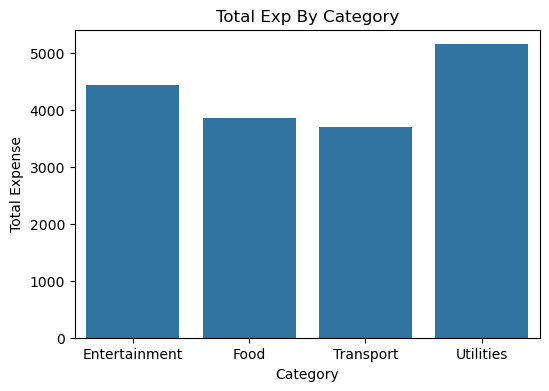

In [35]:
# Bar Chart
data = pd.read_csv("expenses.csv")

# Convert Date column into datetime
data["Date"] = pd.to_datetime(data["Date"])
cat_total=data.groupby("Category")['Amount'].sum()
plt.figure(figsize=(6,4))
sns.barplot(x=cat_total.index,y=cat_total.values)
plt.title("Total Exp By Category")
plt.xlabel("Category")
plt.ylabel("Total Expense")
plt.show()

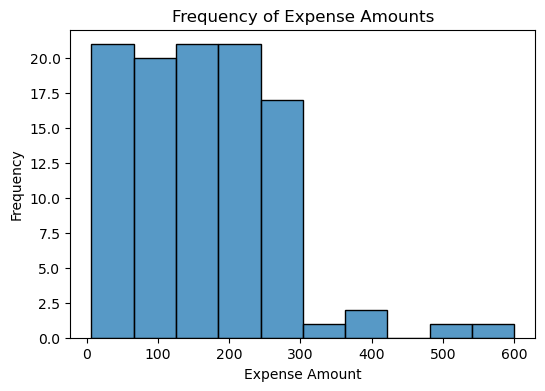

In [36]:
# Histogram 
data=pd.read_csv("expenses.csv")
plt.figure(figsize=(6,4))
sns.histplot(data["Amount"], bins=10)
plt.title("Frequency of Expense Amounts")
plt.xlabel("Expense Amount")
plt.ylabel("Frequency")
plt.show()